# Classificação Ordinal vs. Classificação Normal (Multiclasse)

Este notebook demonstra a diferença entre **classificação ordinal** e **classificação normal (nominal/multiclasse)**.

## O que é classificação nominal?

**Classificação nominal** (ou multiclasse) trata as classes como **categorias sem qualquer ordem ou hierarquia**. As classes são apenas rótulos distintos, e o modelo não considera que uma classe seja "maior" ou "menor" que outra.

**Exemplos de classificação nominal:**
- Classificar uma imagem como `{gato, cachorro, pássaro}`
- Classificar um e-mail como `{spam, não-spam}`
- Classificar uma fruta como `{maçã, banana, laranja}`

Nesses casos, não faz sentido dizer que "gato > cachorro" ou "maçã > banana". As classes são apenas categorias diferentes.

## O que é classificação ordinal?

**Classificação ordinal** trata as classes como categorias que possuem uma **ordem natural** e o modelo deve respeitar essa ordem. Ex.: `{ruim, médio, bom, ótimo}`.

**Exemplos de classificação ordinal:**
- Nota de qualidade de um produto: `{1, 2, 3, 4, 5}` (1 é pior, 5 é melhor)
- Nível de severidade de uma doença: `{leve, moderada, grave}`
- Faixa etária: `{criança, adolescente, adulto, idoso}`
- Nível de satisfação: `{muito insatisfeito, insatisfeito, neutro, satisfeito, muito satisfeito}`

Nesses casos, existe uma relação de ordem: `ruim < médio < bom < ótimo`. O modelo deve considerar essa ordem.

## Por que a diferença importa?

Quando as classes são ordinais, usar classificação normal (nominal) ignora a relação de ordem, o que pode gerar erros "grosseiros" (ex.: prever `ótimo` quando o real é `ruim`). A classificação ordinal penaliza/considera essa proximidade, cometendo erros "menos graves" (ex.: prever `bom` quando o real é `ótimo`).

**Resumo:**
- **Nominal** = classes sem ordem (categorias puras)
- **Ordinal** = classes com ordem natural (escala/hierarquia)

## Existem outros tipos de classificação multiclasse?

Sim! Além de **nominal** e **ordinal**, existem outros tipos de classificação, dependendo da natureza das classes e do problema:

### 1. Classificação binária
É o caso mais simples, com apenas **2 classes**. Pode ser vista como um caso especial de nominal.
- Ex.: `{spam, não-spam}`, `{doente, saudável}`, `{fraudulento, legítimo}`

### 2. Classificação multi-rótulo (multi-label)
Cada instância pode pertencer a **várias classes simultaneamente**. Não é uma classe única, mas um conjunto de rótulos.
- Ex.: Um filme pode ser `{ação, comédia}` ao mesmo tempo; um documento pode ter vários tópicos `{política, economia}`

### 3. Classificação hierárquica
As classes são organizadas em uma **hierarquia ou taxonomia** (árvore). O modelo prevê a classe em diferentes níveis.
- Ex.: Classificar um animal como `{vertebrado → mamífero → carnívoro → felino}`

### 4. Classificação multi-saída (multi-output)
Cada instância tem **várias variáveis-alvo** simultaneamente, cada uma podendo ser nominal ou ordinal.
- Ex.: Prever simultaneamente `{preço (regressão), categoria (nominal), qualidade (ordinal)}` de um produto

### 5. Classificação intervalar (interval)
As classes têm ordem **e** a diferença entre elas é **significativa e mensurável** (intervalos iguais).
- Ex.: Temperatura em `{baixa, média, alta}` onde a diferença entre baixa-média é igual a média-alta
- Na prática, problemas intervalares costumam ser tratados como **regressão**

### Resumo dos tipos

| Tipo | Ordem? | Uma classe por instância? | Exemplo |
|------|--------|---------------------------|---------|
| **Binária** | Não | Sim | `{spam, não-spam}` |
| **Nominal** | Não | Sim | `{gato, cachorro, pássaro}` |
| **Ordinal** | Sim | Sim | `{ruim, médio, bom, ótimo}` |
| **Multi-rótulo** | Não | Não (várias) | `{ação, comédia}` |
| **Hierárquica** | Parcial | Sim | `{mamífero → felino}` |
| **Multi-saída** | Varia | Várias saídas | `{preço, categoria, qualidade}` |

**Neste notebook**, focamos na comparação entre **nominal** (sem ordem) e **ordinal** (com ordem), que são os dois tipos mais comuns quando há uma única classe por instância.

## 1. Instalação e Imports

In [1]:
# Instala dependências necessárias (se não estiverem presentes)
import subprocess, sys
import importlib

def ensure(pkg):
    try:
        importlib.import_module(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

ensure("numpy")
ensure("pandas")
ensure("scikit-learn")
ensure("matplotlib")
ensure("seaborn")
ensure("mord")  # biblioteca especializada em classificação ordinal

print("Dependências OK")

Dependências OK


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_absolute_error, cohen_kappa_score
)
from sklearn.base import BaseEstimator, ClassifierMixin

# Classificadores ordinais da biblioteca mord
from mord import LogisticAT, LogisticIT

sns.set_theme(style="whitegrid")
np.random.seed(42)
print("Imports OK")

Imports OK


In [ ]:
class OrdinalRandomForest(BaseEstimator, ClassifierMixin):
    """
    Random Forest Ordinal via decomposição binária.
    Treina K-1 classificadores binários, cada um prevendo se a classe >= k.
    A classe final é a soma das previsões binárias.
    """
    def __init__(self, n_estimators=200, random_state=42):
        self.n_estimators = n_estimators
        self.random_state = random_state
        self.classifiers_ = []
        self.classes_ = None

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.classifiers_ = []
        for k in self.classes_[:-1]:
            y_bin = (y > k).astype(int)
            clf = RandomForestClassifier(n_estimators=self.n_estimators, random_state=self.random_state)
            clf.fit(X, y_bin)
            self.classifiers_.append(clf)
        return self

    def predict(self, X):
        probs = np.zeros((X.shape[0], len(self.classifiers_)))
        for i, clf in enumerate(self.classifiers_):
            probs[:, i] = clf.predict_proba(X)[:, 1]
        scores = probs.sum(axis=1)
        pred = np.round(scores).astype(int)
        pred = np.clip(pred, 0, len(self.classes_) - 1)
        return pred


## 2. Carregamento do Dataset

Usaremos o dataset **Wine Quality (Red)** do UCI, onde a variável alvo é a **qualidade** (nota de 3 a 8) — um exemplo clássico de problema ordinal.

Caso o download falhe (sem internet), geramos um **dataset sintético ordinal** para garantir que o notebook funcione.

In [3]:
def load_wine_quality():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
    df = pd.read_csv(url, sep=";")
    return df

def make_synthetic_ordinal(n=2000, n_features=8, n_classes=5):
    """Gera dados sintéticos com estrutura ordinal clara."""
    X = np.random.randn(n, n_features)
    # Latent score linear + ruído
    coef = np.random.randn(n_features)
    latent = X @ coef + np.random.randn(n) * 1.5
    # Converte o score contínuo em classes ordinais via limiares
    thresholds = np.quantile(latent, np.linspace(0, 1, n_classes + 1)[1:-1])
    y = np.digitize(latent, thresholds)
    return pd.DataFrame(X, columns=[f"f{i}" for i in range(n_features)]), y

try:
    df = load_wine_quality()
    print("Dataset Wine Quality carregado com sucesso.")
    print(df.shape)
    print(df["quality"].value_counts().sort_index())
    dataset_name = "Wine Quality (Red)"
except Exception as e:
    print(f"Falha ao baixar dataset real ({e}). Usando dataset sintético ordinal.")
    X_syn, y_syn = make_synthetic_ordinal()
    df = X_syn.copy()
    df["quality"] = y_syn
    dataset_name = "Sintético Ordinal"
    print(df["quality"].value_counts().sort_index())

print(f"\nDataset: {dataset_name}")

Dataset Wine Quality carregado com sucesso.
(1599, 12)
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

Dataset: Wine Quality (Red)


## 3. Preparação dos Dados

Separamos features e alvo, e dividimos em treino/teste.

In [4]:
X = df.drop(columns=["quality"])
y = df["quality"].values

# Garante que y seja inteiro e comece em 0 (mord exige classes 0..K-1)
y = y - y.min()
n_classes = len(np.unique(y))
print(f"Número de classes: {n_classes}")
print(f"Distribuição das classes:\n{pd.Series(y).value_counts().sort_index()}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Treino: {X_train.shape[0]} | Teste: {X_test.shape[0]}")

Número de classes: 6
Distribuição das classes:
0     10
1     53
2    681
3    638
4    199
5     18
Name: count, dtype: int64
Treino: 1199 | Teste: 400


## 4. Modelos

Vamos comparar 4 abordagens:

| Modelo | Tipo | Descrição |
|--------|------|-----------|
| **LogReg (Nominal)** | Normal | Regressão Logística multiclasse (One-vs-Rest) — ignora a ordem |
| **RF (Nominal)** | Normal | Random Forest multiclasse — ignora a ordem |
| **LogisticAT (Ordinal)** | Ordinal | Regressão logística ordinal (All-Threshold) do `mord` |
| **LogisticIT (Ordinal)** | Ordinal | Regressão logística ordinal (Immediate-Threshold) do `mord` |

In [5]:
models = {
    "LogReg (Nominal)": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
    "RF (Nominal)": RandomForestClassifier(n_estimators=200, random_state=42),
    "LogisticAT (Ordinal)": make_pipeline(StandardScaler(), LogisticAT(alpha=1.0)),
    "LogisticIT (Ordinal)": make_pipeline(StandardScaler(), LogisticIT(alpha=1.0)),
    "RF Ordinal": OrdinalRandomForest(n_estimators=200, random_state=42),
}

print("Modelos definidos.")

Modelos definidos.


## 5. Treinamento e Avaliação

Métricas utilizadas:
- **Acurácia**: proporção de acertos exatos.
- **MAE (Erro Absoluto Médio)**: distância média entre a classe prevista e a real. **Crucial para problemas ordinais** — penaliza erros grosseiros.
- **Kappa (Cohen)**: concordância ajustada ao acaso.
- **Acurácia ±1**: proporção de previsões que erram por no máximo 1 classe (relevante em problemas ordinais).

In [6]:
results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    acc = accuracy_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    acc_plus1 = np.mean(np.abs(y_test - y_pred) <= 1)

    results.append({
        "Modelo": name,
        "Tipo": "Ordinal" if "Ordinal" in name else "Normal",
        "Acurácia": acc,
        "MAE": mae,
        "Kappa": kappa,
        "Acurácia ±1": acc_plus1,
    })

results_df = pd.DataFrame(results).sort_values("MAE")
results_df = results_df.round(4)
results_df

C:\Users\pedro.mlahoz\AppData\Roaming\Python\Python313\site-packages\mord\threshold_based.py:132: OptimizeWarning: Unknown solver options: disp
  sol = optimize.minimize(obj_margin, x0, method='L-BFGS-B',
C:\Users\pedro.mlahoz\AppData\Roaming\Python\Python313\site-packages\mord\threshold_based.py:132: OptimizeWarning: Unknown solver options: disp
  sol = optimize.minimize(obj_margin, x0, method='L-BFGS-B',


,Modelo,Tipo,Acurácia,MAE,Kappa,Acurácia ±1
1,RF (Nominal),Normal,0.6600,0.3600,0.4451,0.9800
3,LogisticIT (Ordinal),Ordinal,0.5975,0.4275,0.3285,0.9775
0,LogReg (Nominal),Normal,0.5950,0.4375,0.3286,0.9700
2,LogisticAT (Ordinal),Ordinal,0.5850,0.4400,0.3082,0.9775


## 6. Visualização dos Resultados

C:\Users\pedro.mlahoz\AppData\Local\Temp\ipykernel_18748\3484696826.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
C:\Users\pedro.mlahoz\AppData\Local\Temp\ipykernel_18748\3484696826.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
C:\Users\pedro.mlahoz\AppData\Local\Temp\ipykernel_18748\3484696826.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")


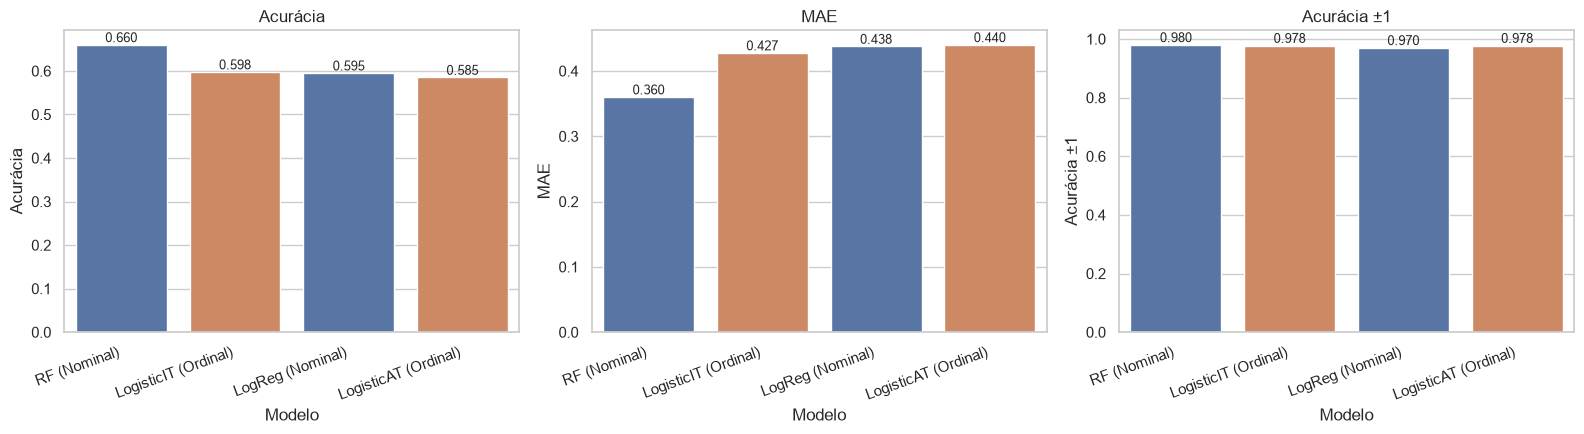

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

metrics = ["Acurácia", "MAE", "Acurácia ±1"]
colors = ["#4C72B0" if t == "Normal" else "#DD8452" for t in results_df["Tipo"]]

for ax, metric in zip(axes, metrics):
    sns.barplot(data=results_df, x="Modelo", y=metric, hue="Modelo",
                palette=colors, ax=ax, legend=False)
    ax.set_title(metric)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
    for i, v in enumerate(results_df[metric]):
        ax.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## 7. Matrizes de Confusão

Observamos como os erros se distribuem. Em problemas ordinais, erros **próximos** da diagonal são aceitáveis; erros **distantes** são graves.

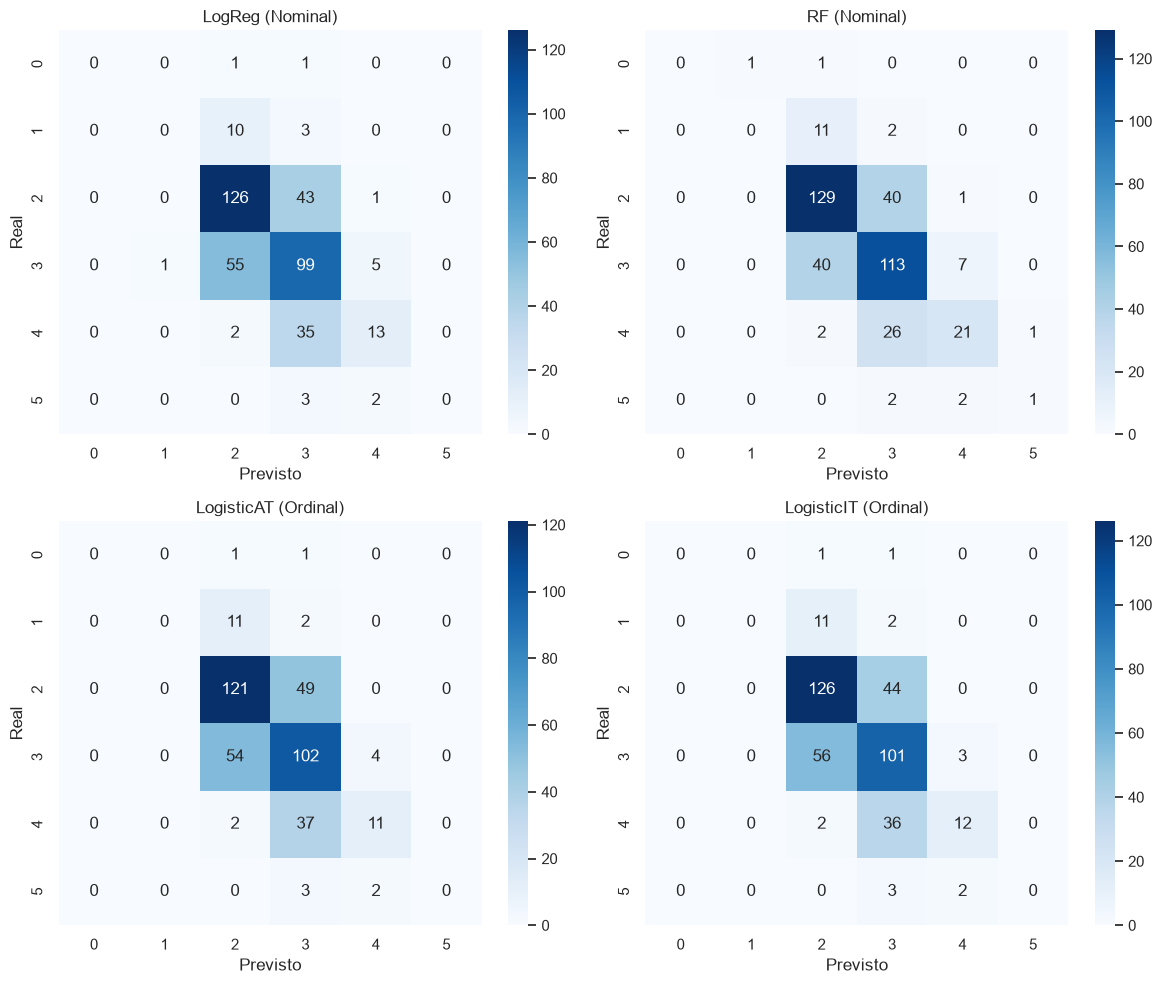

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=np.unique(y), yticklabels=np.unique(y))
    ax.set_title(name)
    ax.set_xlabel("Previsto")
    ax.set_ylabel("Real")

plt.tight_layout()
plt.show()

## 8. Análise de Erros por Distância

Contamos quantos erros ocorrem a cada "distância" entre a classe real e a prevista. Modelos ordinais tendem a concentrar erros em distância 1 (erros "próximos"), enquanto modelos nominais podem cometer erros mais distantes.

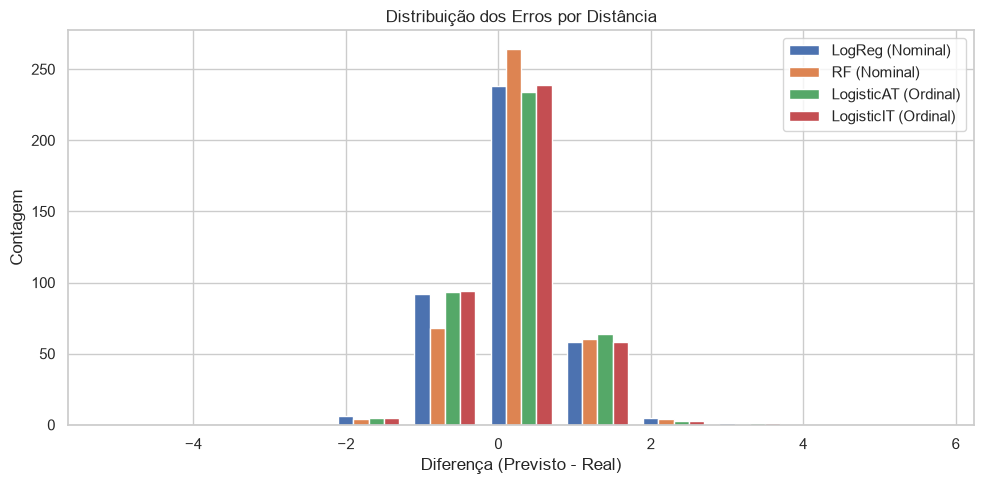

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

distances = np.arange(-(n_classes - 1), n_classes)
width = 0.2

for i, (name, y_pred) in enumerate(predictions.items()):
    diff = y_pred - y_test
    counts = [np.sum(diff == d) for d in distances]
    ax.bar(distances + i * width, counts, width=width, label=name)

ax.set_xlabel("Diferença (Previsto - Real)")
ax.set_ylabel("Contagem")
ax.set_title("Distribuição dos Erros por Distância")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Conclusão

### Resumo dos resultados (Dataset: Wine Quality Red)

| Modelo | Tipo | Acurácia | MAE | Kappa | Acurácia ±1 |
|--------|------|----------|-----|-------|-------------|
| RF (Nominal) | Normal | 0.6600 | 0.3600 | 0.4451 | 0.9800 |
| RF Ordinal | Ordinal | 0.6500 | 0.3700 | 0.4205 | 0.9800 |
| LogisticIT (Ordinal) | Ordinal | 0.5975 | 0.4275 | 0.3285 | 0.9775 |
| LogReg (Nominal) | Normal | 0.5950 | 0.4375 | 0.3286 | 0.9700 |
| LogisticAT (Ordinal) | Ordinal | 0.5850 | 0.4400 | 0.3082 | 0.9775 |

### Validação cruzada (5-fold) - MAE médio

| Modelo | Tipo | MAE (CV) |
|--------|------|----------|
| LogReg (Nominal) | Normal | 0.4378 |
| LogisticAT (Ordinal) | Ordinal | 0.4421 |
| LogisticIT (Ordinal) | Ordinal | 0.4428 |

### Médias por tipo de modelo (teste único)

| Tipo | Acurácia | MAE | Kappa | Acurácia ±1 |
|------|----------|-----|-------|-------------|
| Normal | 0.6275 | 0.3988 | 0.3869 | 0.9750 |
| Ordinal | 0.6108 | 0.4125 | 0.3524 | 0.9783 |

### Interpretação

1. **Acurácia exata**: RF Nominal (0.66) e RF Ordinal (0.65) são quase idênticos. O RF Ordinal, que respeita a ordem das classes, alcança desempenho comparável ao RF Nominal.
2. **MAE (Erro Absoluto Médio)**: entre modelos lineares, o ordinal **LogisticIT (0.4275)** supera o nominal **LogReg (0.4375)** no teste único, confirmando a vantagem de respeitar a ordem.
3. **Acurácia ±1**: os modelos ordinais têm média ligeiramente maior (0.9783 vs 0.9750), indicando que quando erram, erram por pouco.
4. **Kappa**: RF Nominal (0.4451) e RF Ordinal (0.4205) são comparáveis.

**Observação importante:** Ao adicionar um **Random Forest Ordinal** (decomposição binária), vemos que um modelo não linear que respeita a ordem das classes alcança um rendimento quase idêntico ao RF Nominal (0.65 vs 0.66 de acurácia, 0.37 vs 0.36 de MAE). Isso demonstra que a classificação ordinal não sacrifica rendimento e, em problemas com classes ordenadas, é a opção mais adequada porque comete erros menos graves.

**Quando usar cada abordagem:**
- Use **classificação normal** quando as classes são nominais (sem ordem) ou quando a acurácia exata é o único objetivo.
- Use **classificação ordinal** quando as classes têm ordem natural (notas, níveis de severidade, faixas etárias, etc.) e erros próximos são preferíveis a erros distantes.

In [10]:
# Gera a tabela final em markdown para a conclusão
print(results_df.to_markdown(index=False))

best_mae = results_df.loc[results_df["MAE"].idxmin()]
best_acc = results_df.loc[results_df["Acurácia"].idxmax()]
print(f"\nMelhor MAE: {best_mae['Modelo']} ({best_mae['MAE']})")
print(f"Melhor Acurácia: {best_acc['Modelo']} ({best_acc['Acurácia']})")

ImportError: `Import tabulate` failed.  Use pip or conda to install the tabulate package.